Main goal is to idenify the mechanism to inflation and correlations between the inflated radii and any planetary or stellar
charactertisics. Our main questions to answer are:
•	How does the degree of inflation depend on incident flux? 
•	Are there correlations with host star properties such as mass or metallicity? 
•	How large are the observational uncertainties, and how do they affect your conclusions? 
•	Compare your results to simple theoretical expectations for gas giant structure. 
•	What do your findings suggest about the physical processes operating in these atmospheres?



First, we fetch and clean the data.

In [25]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Reads Data from NASA Exoplanet Archive
df = pd.read_csv("./PSCompPars_2026.03.16_20.49.11.csv", comment='#')
df.columns = df.columns.str.strip()

# Clean Data
# Clean to keep Radius, Equilibrium Temperature, Flux, Orbital Period, Metallicity, Mass, Radius Error
df = df[['pl_rade', 'pl_eqt', 'pl_insol', 'pl_orbper', 'st_met', 'pl_bmasse', 'st_mass', 'pl_radeerr2', 'pl_radeerr1']]
# Clean missing values in Data
hj = df.dropna(subset=['pl_rade', 'pl_eqt', 'pl_insol', 'pl_orbper', 'st_met', 'pl_bmasse', 'st_mass', 'pl_radeerr2', 'pl_radeerr1'])
print(hj.head())

    pl_rade  pl_eqt  pl_insol  pl_orbper  st_met  pl_bmasse  st_mass  \
0  8.097382   739.3   49.5800   7.327947   0.099  39.855882   0.7311   
1  8.140000  1038.0  149.0000   9.127055   0.439  81.700000   1.0820   
3  8.200000  1038.0  373.1080   4.583522   0.050  51.100000   1.1800   
4  8.294646   690.0   39.0000   3.936551   0.400  82.635386   0.6300   
5  8.339482   555.4   17.0012   3.471683   0.357  79.774930   0.4420   

   pl_radeerr2  pl_radeerr1  
0    -0.035869     0.035869  
1    -0.300000     0.310000  
3    -1.390000     3.710000  
4    -0.224180     0.224180  
5    -0.190553     0.190553  


Plot radius with temperature and flux to determine if there is a clear transition when the inflation becomes significant.

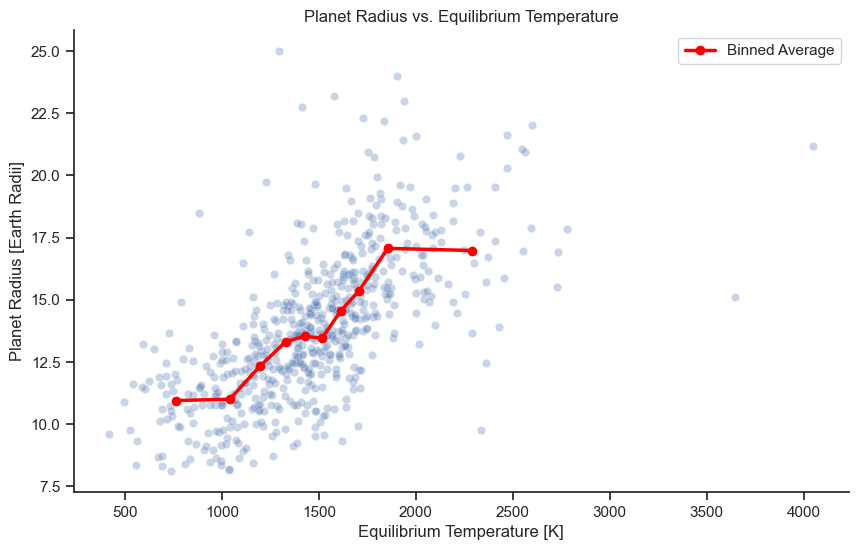

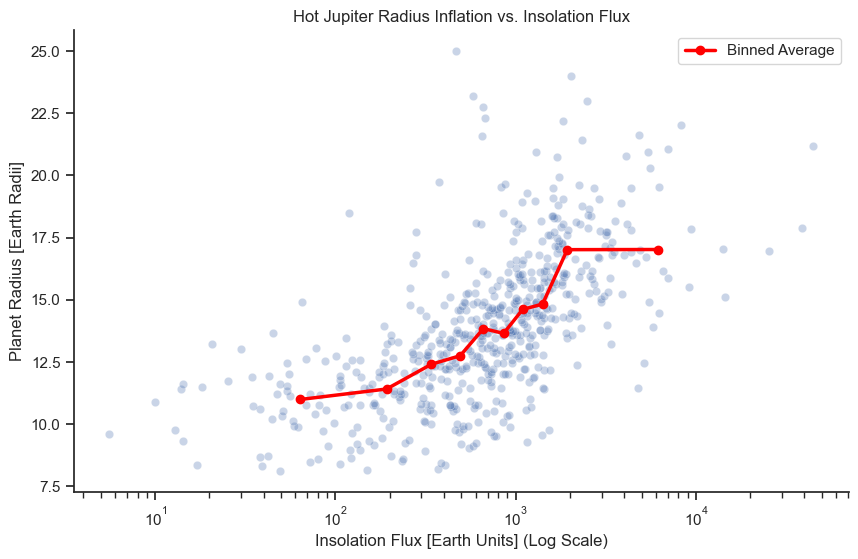

In [51]:
# Create temperature bins
hj['temp_bins'] = pd.qcut(hj['pl_eqt'], q=10)
temp_analysis = hj.groupby('temp_bins', observed=True).agg({'pl_eqt': 'mean', 'pl_rade': 'mean'}).sort_values('pl_eqt').reset_index()

# Temperature vs Radius Plot
plt.figure(figsize=(10,6))
sns.scatterplot(data=hj, x='pl_eqt', y='pl_rade', alpha=0.3)
plt.plot(temp_analysis['pl_eqt'], temp_analysis['pl_rade'], 
         color='red', marker='o', linewidth=2.5, label='Binned Average')
plt.title('Planet Radius vs. Equilibrium Temperature')
plt.xlabel('Equilibrium Temperature [K]')
plt.ylabel('Planet Radius [Earth Radii]')
sns.despine()
plt.legend()
plt.show()



#Create flux bins
hj['flux_bins'] = pd.qcut(hj['pl_insol'], q=10)
bin_stats = hj.groupby('flux_bins', observed=True).agg({'pl_insol': 'mean', 'pl_rade': 'mean'}).sort_values('pl_insol').reset_index()

# Flux vs Radius Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=hj, x='pl_insol', y='pl_rade', alpha=0.3,)
plt.plot(bin_stats['pl_insol'], bin_stats['pl_rade'], color='red', marker='o', linewidth=2.5, label='Binned Average')
plt.xscale('log')
plt.title('Hot Jupiter Radius Inflation vs. Insolation Flux')
plt.xlabel('Insolation Flux [Earth Units] (Log Scale)')
plt.ylabel('Planet Radius [Earth Radii]')
plt.legend()
sns.despine()
plt.show()



The degree of inflation is positively correlated with incident flux and equilibrium temperature. Thus suggests that the inflated nature of these planets are a direct link to stellar irradiation preventing the planets from cooling and contracting.


Plot relationship between planet inflation and metallicity: Are there correlations with host star properties such as metallicity?

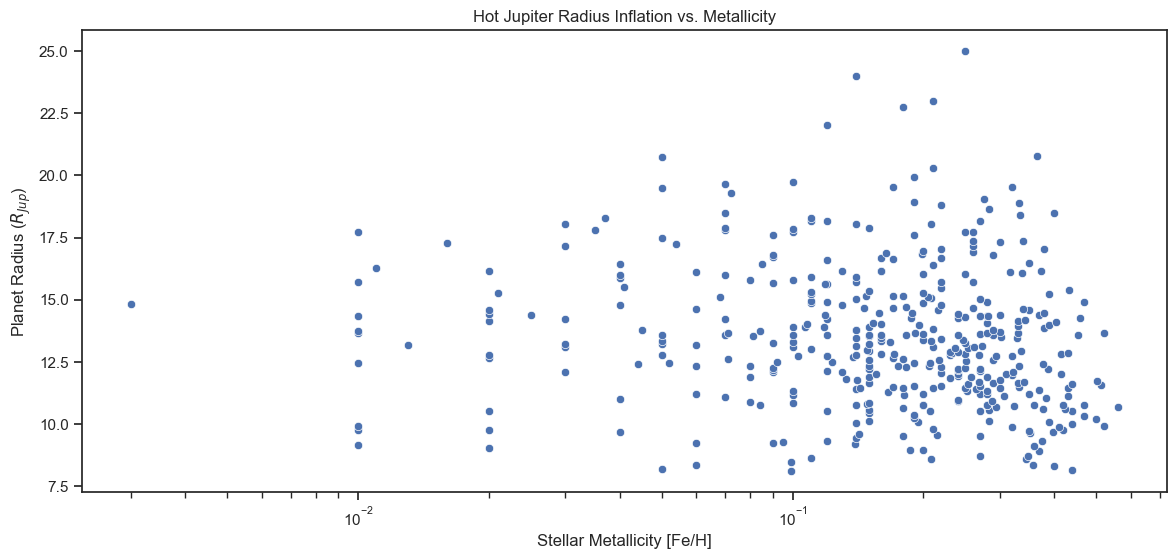

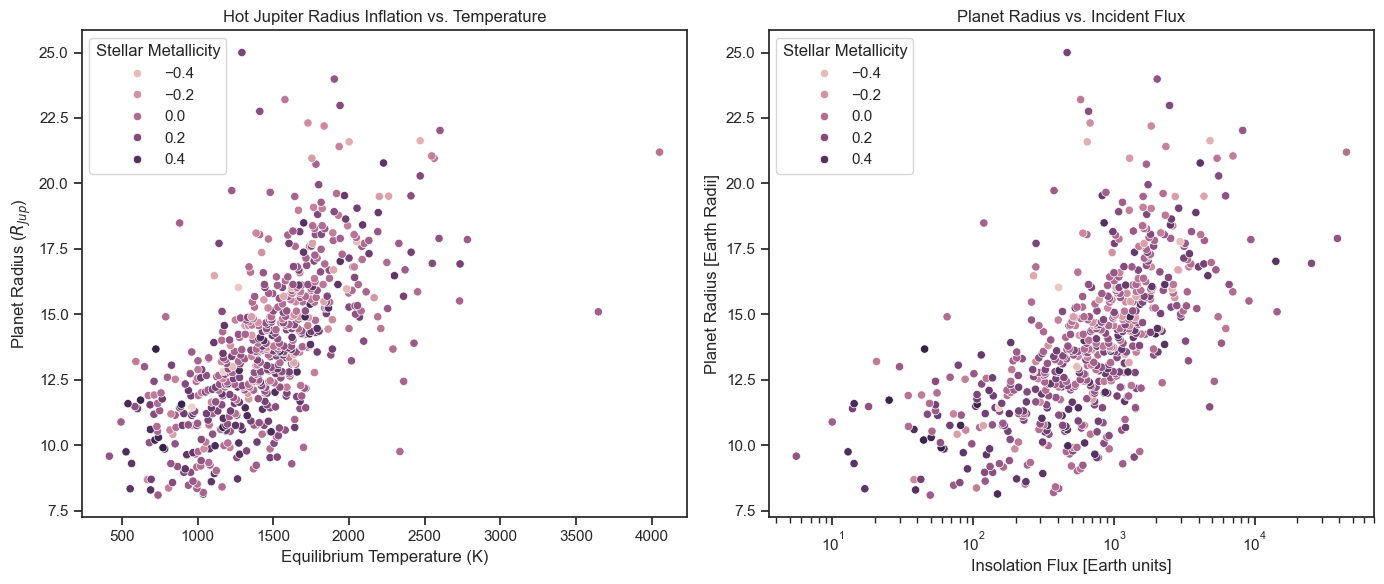

In [52]:
# Plot Inflation vs Metallicity
plt.figure(figsize=(14,6))
me = sns.scatterplot(data=hj, x='st_met', y='pl_rade')
me.set_xscale('log')
me.set_xlabel('Stellar Metallicity [Fe/H]')
me.set_ylabel('Planet Radius [Earth Radii]')
me.set_title('Hot Jupiter Radius Inflation vs. Metallicity')

#Plot following as subplots
fig, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 6))

# Plot Correlation between Metallicty relate to inflation
sns.scatterplot(data=hj, x='pl_eqt', y='pl_rade', hue='st_met', ax=ax3)
ax3.set_xlabel('Equilibrium Temperature (K)')
ax3.set_ylabel('Planet Radius [Earth Radii]')
ax3.set_title('Hot Jupiter Radius Inflation vs. Temperature')
ax3.legend_.set_title("Stellar Metallicity")

# Flux vs Radius Plot
sns.scatterplot(data=hj, x='pl_insol', y='pl_rade', hue='st_met', ax=ax4)
ax4.set_xscale('log')
ax4.set_title('Planet Radius vs. Incident Flux')
ax4.set_xlabel('Insolation Flux [Earth units]')
ax4.set_ylabel('Planet Radius [Earth Radii]')
ax4.legend_.set_title("Stellar Metallicity")

plt.tight_layout()
plt.show()




Plot relationship between inflation and mass: Are there correlations with host star properties such as Mass?

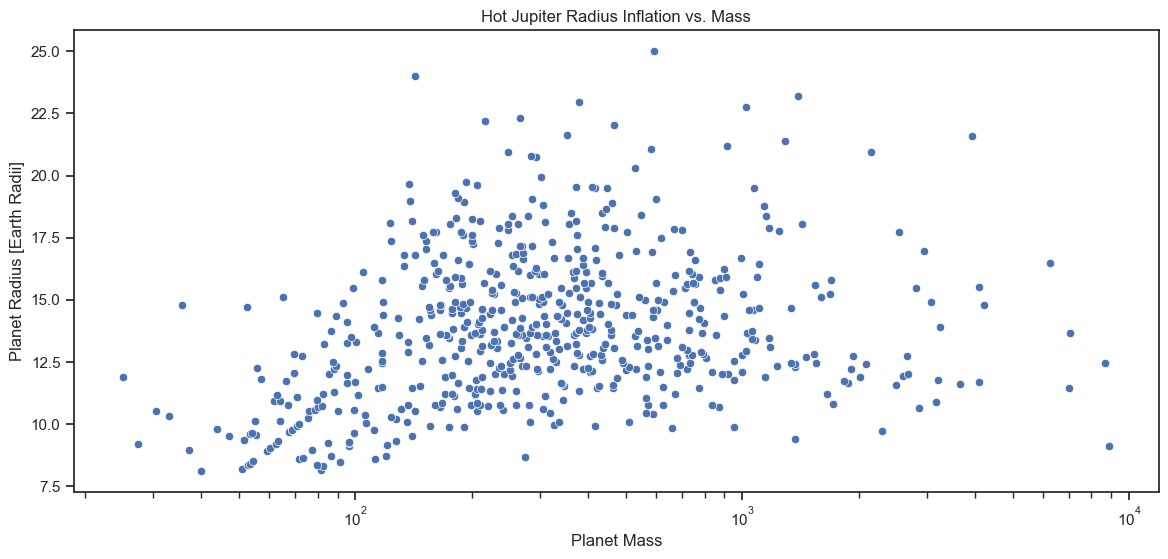

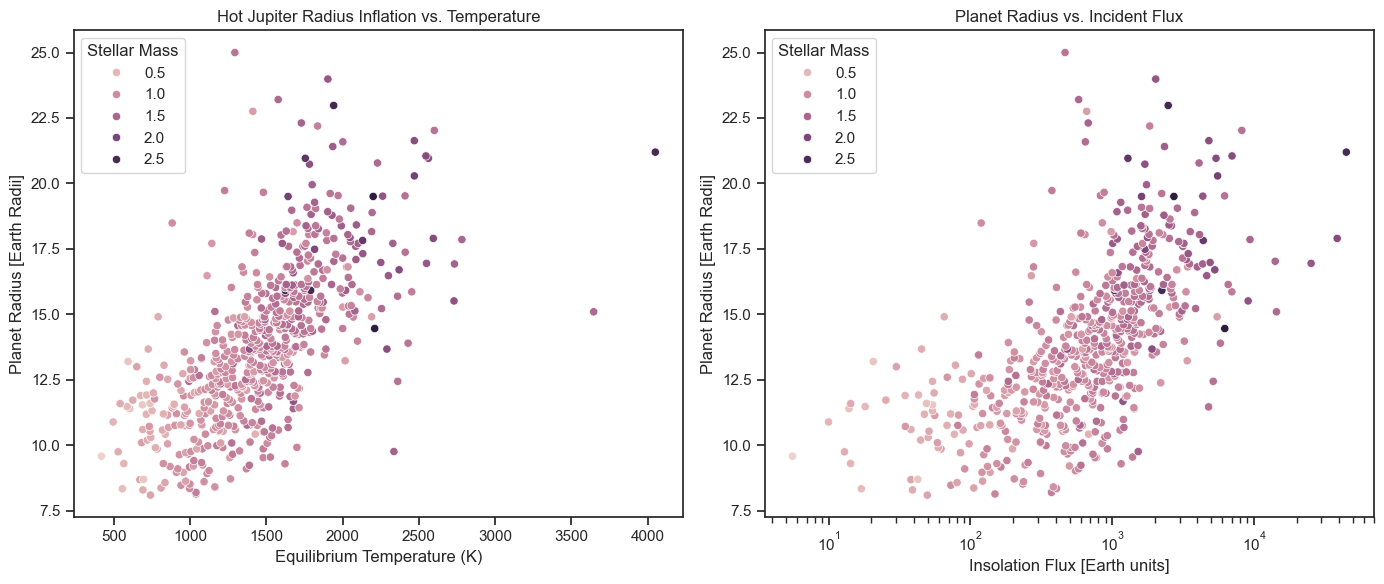

In [53]:
# Plot for correlation between Mass and Inflation
plt.figure(figsize=(14,6))
mas = sns.scatterplot(data=hj, x='pl_bmasse', y='pl_rade')
mas.set_xscale('log')
mas.set_xlabel('Planet Mass')
mas.set_ylabel('Planet Radius [Earth Radii]')
mas.set_title('Hot Jupiter Radius Inflation vs. Mass')

# Set up subplots for following plots
fig, (ax5, ax6) = plt.subplots(1, 2, figsize=(14, 6))

# PLot Correlation between Metallicty relate to inflation
sns.scatterplot(data=hj, x='pl_eqt', y='pl_rade', hue='st_mass', ax=ax5)
ax5.set_xlabel('Equilibrium Temperature (K)')
ax5.set_ylabel('Planet Radius [Earth Radii]')
ax5.set_title('Hot Jupiter Radius Inflation vs. Temperature')
ax5.legend_.set_title("Stellar Mass")

# Flux vs Radius Plot
sns.scatterplot(data=hj, x='pl_insol', y='pl_rade', hue='st_mass', ax=ax6)
ax6.set_xscale('log')
ax6.set_title('Planet Radius vs. Incident Flux')
ax6.set_xlabel('Insolation Flux [Earth units]')
ax6.set_ylabel('Planet Radius [Earth Radii]')
ax6.legend_.set_title("Stellar Mass")

plt.tight_layout()
plt.show()

Observational Uncertainties: How large are uncertainties and how do they affect conclusions?

<ErrorbarContainer object of 3 artists>

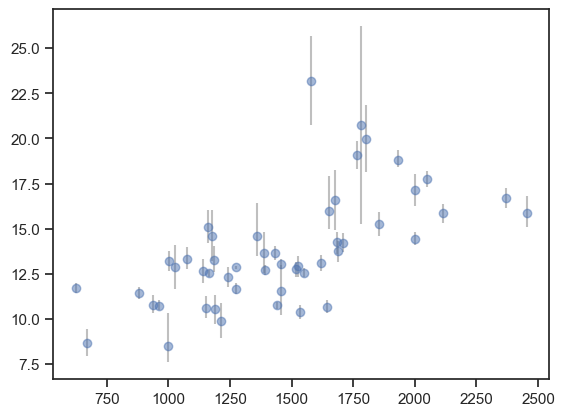

In [22]:
sample = hj.sample(50) 
plt.errorbar(sample['pl_eqt'], sample['pl_rade'], yerr=[sample['pl_radeerr2'].abs(), sample['pl_radeerr1']], 
             fmt='o', alpha=0.5, ecolor='gray')

Comparison with theoretical model: Compare results to simple theoretical expectations for gas siant structures.
1.1 -> 12.32 (Earth Radii)

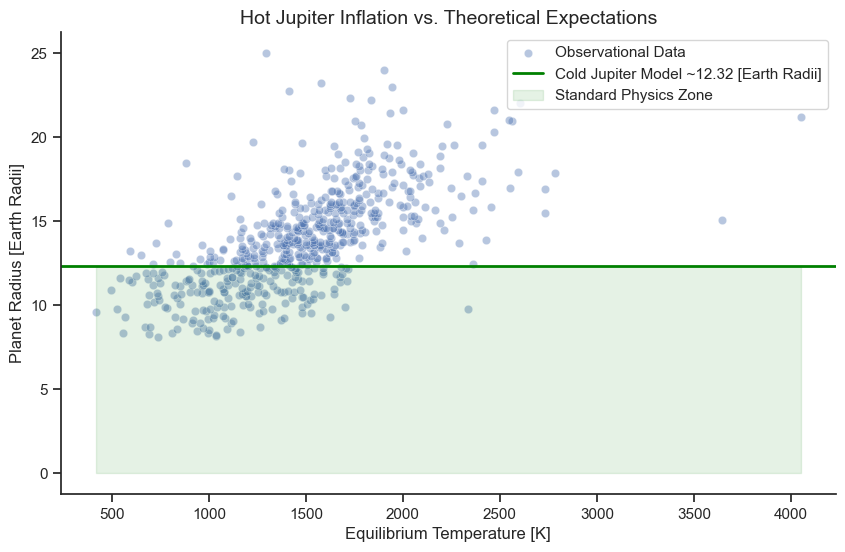

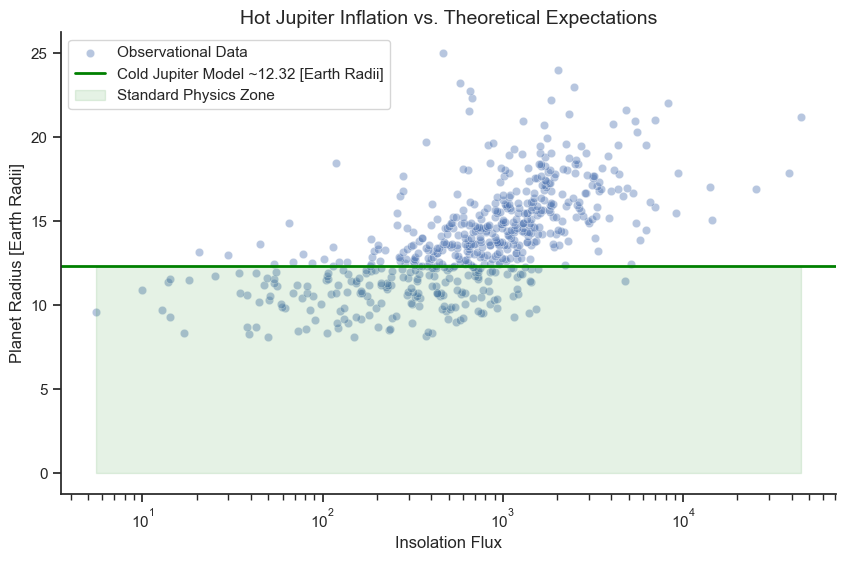

In [54]:
cold_jupiter_limit = 12.32 

plt.figure(figsize=(10,6))
sns.scatterplot(data=hj, x='pl_eqt', y='pl_rade', alpha=0.4, label='Observational Data')
plt.axhline(y=cold_jupiter_limit, color='green', linestyle='-', linewidth=2, 
            label=f'Cold Jupiter Model ~{cold_jupiter_limit} [Earth Radii]')
x_values = np.linspace(hj['pl_eqt'].min(), hj['pl_eqt'].max(), 100)
plt.fill_between(x_values, 0, cold_jupiter_limit, color='green', alpha=0.1, 
                 label='Standard Physics Zone')
plt.title('Hot Jupiter Inflation vs. Theoretical Expectations', fontsize=14)
plt.xlabel('Equilibrium Temperature [K]')
plt.ylabel('Planet Radius [Earth Radii]')
plt.legend()
sns.despine()
plt.show()



plt.figure(figsize=(10,6))
sns.scatterplot(data=hj, x='pl_insol', y='pl_rade', alpha=0.4, label='Observational Data')
plt.axhline(y=cold_jupiter_limit, color='green', linestyle='-', linewidth=2, 
            label=f'Cold Jupiter Model ~{cold_jupiter_limit} [Earth Radii]')
x_values = np.linspace(hj['pl_insol'].min(), hj['pl_insol'].max(), 100)
plt.fill_between(x_values, 0, cold_jupiter_limit, color='green', alpha=0.1, 
                 label='Standard Physics Zone')
plt.title('Hot Jupiter Inflation vs. Theoretical Expectations', fontsize=14)
plt.xscale('log')
plt.xlabel('Insolation Flux')
plt.ylabel('Planet Radius [Earth Radii]')
plt.legend()
sns.despine()
plt.show()